In [ ]:
# Cell 1: 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_moons, make_blobs
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, mean_squared_error

# 设置随机种子以保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 设置画图支持中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows/Linux 可改为 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

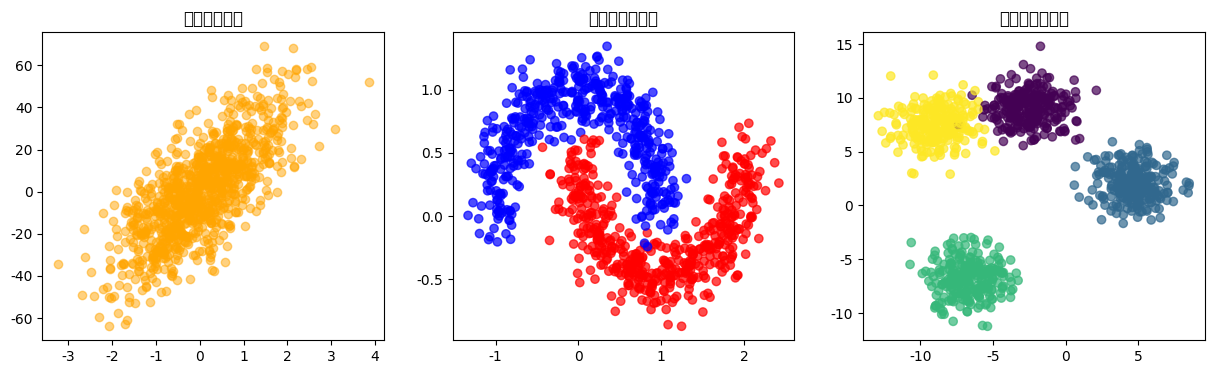

In [2]:
# Cell 2: 生成回归、二分类、多分类数据集并转化为 Tensor
num_samples = 1000

# 1. 回归任务数据 (一维特征 -> 一维输出，加入噪声)
X_reg, y_reg = make_regression(n_samples=num_samples, n_features=1, noise=15.0, random_state=42)
X_reg, y_reg = torch.tensor(X_reg, dtype=torch.float32), torch.tensor(y_reg, dtype=torch.float32).view(-1, 1)

# 2. 二分类任务数据 (月亮形状数据集)
X_bin, y_bin = make_moons(n_samples=num_samples, noise=0.15, random_state=42)
X_bin, y_bin = torch.tensor(X_bin, dtype=torch.float32), torch.tensor(y_bin, dtype=torch.float32).view(-1, 1)

# 3. 多分类任务数据 (4个聚类中心，用于多分类)
X_mul, y_mul = make_blobs(n_samples=num_samples, n_features=2, centers=4, cluster_std=1.5, random_state=42)
X_mul, y_mul = torch.tensor(X_mul, dtype=torch.float32), torch.tensor(y_mul, dtype=torch.long)

# 可视化数据集 (加分项)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_reg.numpy(), y_reg.numpy(), alpha=0.5, color='orange')
axes[0].set_title("回归任务数据")
axes[1].scatter(X_bin[:, 0].numpy(), X_bin[:, 1].numpy(), c=y_bin.numpy(), cmap='bwr', alpha=0.7)
axes[1].set_title("二分类任务数据")
axes[2].scatter(X_mul[:, 0].numpy(), X_mul[:, 1].numpy(), c=y_mul.numpy(), cmap='viridis', alpha=0.7)
axes[2].set_title("多分类任务数据")
plt.show()

In [5]:
# Cell 3: 手动实现单隐藏层前馈神经网络 (已修复叶子节点问题)
def relu(X):
    return torch.max(X, torch.zeros_like(X))

class ManualFNN:
    def __init__(self, num_inputs, num_hiddens, num_outputs):
        # 【修正】先进行随机初始化和乘法缩放，最后调用 .requires_grad_() 设置为叶子节点
        self.W1 = (torch.randn(num_inputs, num_hiddens) * 0.01).requires_grad_()
        self.b1 = torch.zeros(num_hiddens, requires_grad=True)
        self.W2 = (torch.randn(num_hiddens, num_outputs) * 0.01).requires_grad_()
        self.b2 = torch.zeros(num_outputs, requires_grad=True)
        self.params = [self.W1, self.b1, self.W2, self.b2]
        
    def forward(self, X):
        X = X.reshape((-1, self.W1.shape[0]))
        H = relu(torch.mm(X, self.W1) + self.b1)
        return torch.mm(H, self.W2) + self.b2

# 训练逻辑辅助函数
def train_manual_model(model, X, y, task_type, epochs=100, lr=0.1):
    losses = []
    for epoch in range(epochs):
        y_hat = model.forward(X)
        
        if task_type == 'regression':
            loss = torch.mean((y_hat - y)**2)
        elif task_type == 'binary':
            y_hat_prob = torch.sigmoid(y_hat)
            loss = -torch.mean(y * torch.log(y_hat_prob + 1e-7) + (1 - y) * torch.log(1 - y_hat_prob + 1e-7))
        else: # multi
            y_hat_exp = torch.exp(y_hat - torch.max(y_hat, dim=1, keepdim=True).values) # 防溢出
            partition = y_hat_exp.sum(1, keepdim=True)
            prob = y_hat_exp / partition
            loss = -torch.log(prob[range(len(prob)), y] + 1e-7).mean()
            
        loss.backward()
        with torch.no_grad():
            for param in model.params:
                param -= lr * param.grad
                param.grad.zero_()
        losses.append(loss.item())
    return losses

# 测试手动模型
manual_reg_model = ManualFNN(1, 10, 1)
manual_bin_model = ManualFNN(2, 10, 1)
manual_mul_model = ManualFNN(2, 10, 4)

loss_r = train_manual_model(manual_reg_model, X_reg, y_reg, 'regression')
loss_b = train_manual_model(manual_bin_model, X_bin, y_bin, 'binary')
loss_m = train_manual_model(manual_mul_model, X_mul, y_mul, 'multi', lr=0.5)

print(f"手动实现 FNN 训练完毕 | 回归 Loss: {loss_r[-1]:.4f} | 二分类 Loss: {loss_b[-1]:.4f} | 多分类 Loss: {loss_m[-1]:.4f}")

手动实现 FNN 训练完毕 | 回归 Loss: 483.7443 | 二分类 Loss: 0.6897 | 多分类 Loss: 0.0488


In [6]:
# Cell 4: 利用 torch.nn 实现
class TorchFNN(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, out_features)
        )
        
    def forward(self, X):
        return self.net(X)

def train_torch_model(model, criterion, X, y, epochs=100, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        y_hat = model(X)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

torch_reg_model = TorchFNN(1, 10, 1)
torch_bin_model = TorchFNN(2, 10, 1)
torch_mul_model = TorchFNN(2, 10, 4)

loss_tr = train_torch_model(torch_reg_model, nn.MSELoss(), X_reg, y_reg)
# BCEWithLogitsLoss 内部集成了 Sigmoid
loss_tb = train_torch_model(torch_bin_model, nn.BCEWithLogitsLoss(), X_bin, y_bin)
loss_tm = train_torch_model(torch_mul_model, nn.CrossEntropyLoss(), X_mul, y_mul, lr=0.5)

print(f"PyTorch FNN 训练完毕 | 回归 Loss: {loss_tr[-1]:.4f} | 二分类 Loss: {loss_tb[-1]:.4f} | 多分类 Loss: {loss_tm[-1]:.4f}")

PyTorch FNN 训练完毕 | 回归 Loss: 483.7443 | 二分类 Loss: 0.3977 | 多分类 Loss: 0.0492


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

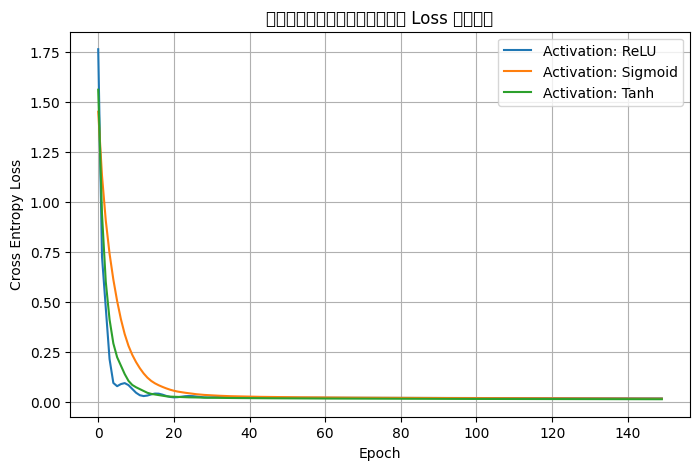

In [7]:
# Cell 5: 探究不同激活函数 (ReLU, Sigmoid, Tanh)
activation_funcs = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh()
}

plt.figure(figsize=(8, 5))
criterion = nn.CrossEntropyLoss()

for name, act_fn in activation_funcs.items():
    model = nn.Sequential(
        nn.Linear(2, 16),
        act_fn,
        nn.Linear(16, 4)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    losses = []
    for epoch in range(150):
        optimizer.zero_grad()
        loss = criterion(model(X_mul), y_mul)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    
    plt.plot(losses, label=f'Activation: {name}')

plt.title("不同激活函数在多分类任务上的 Loss 曲线对比")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

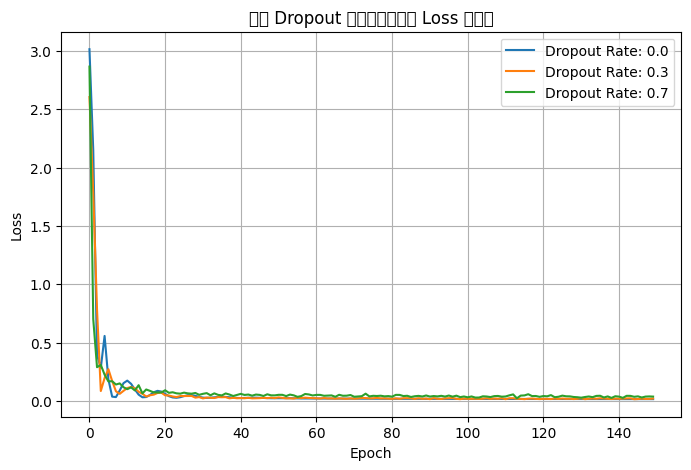

In [8]:
# Cell 6: Dropout 的手动实现与对比
# 手动 Dropout 逻辑
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1: return torch.zeros_like(X)
    if dropout == 0: return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

# 使用 PyTorch 探究不同 Dropout 丢弃率
dropout_rates = [0.0, 0.3, 0.7]
plt.figure(figsize=(8, 5))

for p in dropout_rates:
    model = nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Dropout(p), # PyTorch 实现的 Dropout
        nn.Linear(64, 4)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    losses = []
    
    model.train() # 开启训练模式启用 dropout
    for epoch in range(150):
        optimizer.zero_grad()
        loss = criterion(model(X_mul), y_mul)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    plt.plot(losses, label=f'Dropout Rate: {p}')

plt.title("不同 Dropout 率对多分类训练 Loss 的影响")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

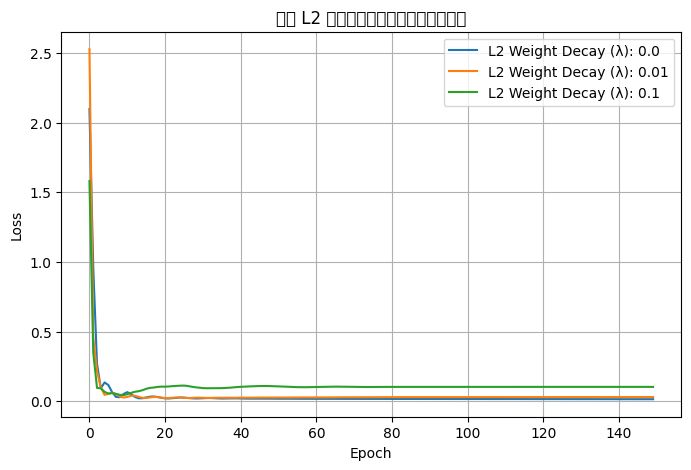

In [9]:
# Cell 7: L2 正则化 (Weight Decay) 探究
# 手动 L2 惩罚项计算: l2_penalty = (torch.sum(W1**2) + torch.sum(W2**2)) * lambda / 2
weight_decays = [0.0, 0.01, 0.1]
plt.figure(figsize=(8, 5))

for wd in weight_decays:
    model = nn.Sequential(
        nn.Linear(2, 32),
        nn.ReLU(),
        nn.Linear(32, 4)
    )
    # PyTorch 实现 L2 正则化：直接在优化器中设置 weight_decay 参数
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05, weight_decay=wd)
    losses = []
    
    for epoch in range(150):
        optimizer.zero_grad()
        loss = criterion(model(X_mul), y_mul)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    plt.plot(losses, label=f'L2 Weight Decay (λ): {wd}')

plt.title("不同 L2 正则化权重对多分类训练的影响")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [10]:
# Cell 8: 对三大任务效果最好的模型使用 10 折交叉验证进行评估
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

def evaluate_cv(X, y, task_type):
    metrics = []
    # 将 Tensor 转回 numpy 方便通过 sklearn 划分折数
    X_np, y_np = X.numpy(), y.numpy()
    
    for train_idx, val_idx in kfold.split(X_np):
        X_train, y_train = torch.tensor(X_np[train_idx]), torch.tensor(y_np[train_idx])
        X_val, y_val = torch.tensor(X_np[val_idx]), torch.tensor(y_np[val_idx])
        
        # 针对任务定义网络和优化器
        if task_type == 'regression':
            model = TorchFNN(1, 16, 1)
            crit = nn.MSELoss()
            epochs, lr = 150, 0.05
        elif task_type == 'binary':
            model = TorchFNN(2, 16, 1)
            crit = nn.BCEWithLogitsLoss()
            epochs, lr = 150, 0.1
        else: # multi
            model = TorchFNN(2, 16, 4)
            crit = nn.CrossEntropyLoss()
            epochs, lr = 150, 0.1
            
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        
        # 训练模型
        for _ in range(epochs):
            optimizer.zero_grad()
            loss = crit(model(X_train), y_train)
            loss.backward()
            optimizer.step()
            
        # 验证模型
        with torch.no_grad():
            y_pred = model(X_val)
            if task_type == 'regression':
                metric = mean_squared_error(y_val.numpy(), y_pred.numpy())
            elif task_type == 'binary':
                preds = (torch.sigmoid(y_pred) > 0.5).float()
                metric = accuracy_score(y_val.numpy(), preds.numpy())
            else: # multi
                preds = torch.argmax(y_pred, dim=1)
                metric = accuracy_score(y_val.numpy(), preds.numpy())
        metrics.append(metric)
        
    return np.mean(metrics), np.std(metrics)

print("=== 10 折交叉验证结果 ===")
reg_mean, reg_std = evaluate_cv(X_reg, y_reg, 'regression')
print(f"回归任务 MSE (越低越好): 平均值 = {reg_mean:.4f}, 标准差 = {reg_std:.4f}")

bin_mean, bin_std = evaluate_cv(X_bin, y_bin, 'binary')
print(f"二分类任务 Accuracy (越高越好): 平均值 = {bin_mean:.4f}, 标准差 = {bin_std:.4f}")

mul_mean, mul_std = evaluate_cv(X_mul, y_mul, 'multi')
print(f"多分类任务 Accuracy (越高越好): 平均值 = {mul_mean:.4f}, 标准差 = {mul_std:.4f}")

=== 10 折交叉验证结果 ===
回归任务 MSE (越低越好): 平均值 = 223.0902, 标准差 = 32.1138
二分类任务 Accuracy (越高越好): 平均值 = 0.9910, 标准差 = 0.0094
多分类任务 Accuracy (越高越好): 平均值 = 0.9940, 标准差 = 0.0066


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

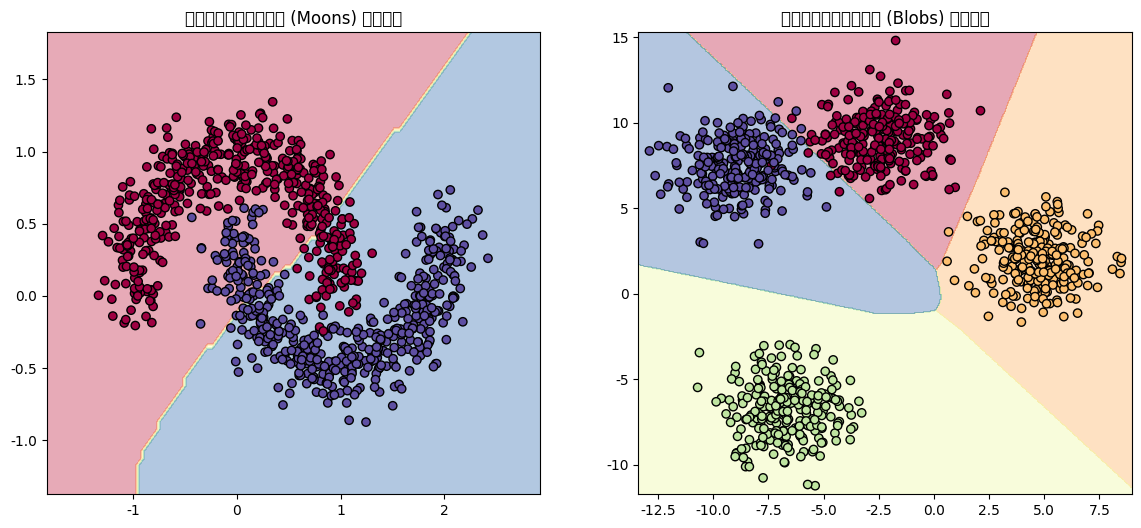

In [11]:
# Cell 9: 绘制模型的决策边界 (Decision Boundary)
def plot_decision_boundary(model, X, y, task_type='binary', title="Decision Boundary"):
    # 设定坐标轴边界并增加一点留白
    x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
    y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5
    h = 0.05  # 网格步长
    
    # 生成网格点
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # 将网格点转换为 Tensor 传入模型
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    model.eval() # 切换到评估模式 (关闭 Dropout 等)
    with torch.no_grad():
        outputs = model(grid_tensor)
        if task_type == 'binary':
            # 二分类：使用 Sigmoid 后大于 0.5 的为正类
            preds = (torch.sigmoid(outputs) > 0.5).float()
        else:
            # 多分类：取 softmax/logits 最大的索引
            preds = torch.argmax(outputs, dim=1)
            
    Z = preds.numpy().reshape(xx.shape)
    
    # 绘制等高线图作为决策边界
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='Spectral')
    
    # 叠加真实的散点数据 (由于 y 可能是 2D 张量，这里用 squeeze() 转为 1D)
    y_plot = y.squeeze().numpy()
    plt.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=y_plot, cmap='Spectral', edgecolors='k')
    plt.title(title)

# 开始绘图
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# 传入在 Cell 4 中训练好的二分类模型 torch_bin_model
plot_decision_boundary(torch_bin_model, X_bin, y_bin, task_type='binary', title="前馈神经网络：二分类 (Moons) 决策边界")

plt.subplot(1, 2, 2)
# 传入在 Cell 4 中训练好的多分类模型 torch_mul_model
plot_decision_boundary(torch_mul_model, X_mul, y_mul, task_type='multi', title="前馈神经网络：多分类 (Blobs) 决策边界")

plt.show()